<div align="center">

# 🐱🐶 Cat vs Dog Image Classification using SVM
### SkillCraft Technology | Machine Learning Internship — Task 03

---

| Detail | Info |
|--------|------|
| **Algorithm** | Support Vector Machine (SVM) — RBF Kernel |
| **Dataset** | Kaggle Dogs vs. Cats (PetImages) |
| **Preprocessing** | Grayscale → Resize → Normalize → PCA |
| **Framework** | scikit-learn, Pillow, Matplotlib |
| **Environment** | Google Colab / Jupyter Notebook |

</div>

##  Table of Contents
1. [Install & Setup (Colab)](#section-0)
2. [Import Libraries](#section-1)
3. [Dataset Loading](#section-2)
4. [Image Preprocessing](#section-3)
5. [Feature Extraction — PCA](#section-4)
6. [Train-Test Split](#section-5)
7. [Model Building — SVM](#section-6)
8. [Model Evaluation](#section-7)
9. [Sample Prediction Visualization](#section-8)
10. [Prediction on New Image](#section-9)
11. [Model Summary](#section-10)

---
##  Section 0 — Install & Dataset Setup (Google Colab)
> Run this section **only** in Google Colab to download the Kaggle dataset.

In [1]:
# ──────────────────────────────────────────────────────────────
# COLAB SETUP  ▸  Run this cell ONLY in Google Colab
# ──────────────────────────────────────────────────────────────

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Install dependencies
    !pip install -q kaggle tqdm Pillow

    # Upload your kaggle.json API token
    from google.colab import files
    print("Upload your kaggle.json file:")
    files.upload()

    # Configure Kaggle credentials
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download the dataset
    !kaggle datasets download -d salader/dogs-vs-cats --path /content/ --unzip

    print("\n✅ Dataset downloaded and extracted to /content/")
    !ls /content/
else:
    print("ℹ️  Not in Colab. Ensure DATASET_PATH is set correctly in Section 2.")

ℹ️  Not in Colab. Ensure DATASET_PATH is set correctly in Section 2.


---
## Section 1 — Import Libraries
> All required libraries for data handling, image processing, machine learning, and visualization.

In [2]:
# ──────────────────────────────────────────────────────────────
# SECTION 1 ▸ IMPORT LIBRARIES
# ──────────────────────────────────────────────────────────────

# ── Standard Library ──────────────────────────────────────────
import os
import glob
import warnings

# ── Numerical Computing ────────────────────────────────────────
import numpy as np

# ── Image Processing ───────────────────────────────────────────
from PIL import Image
from tqdm import tqdm
from skimage.feature import hog   # HOG feature extraction

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Machine Learning ───────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# ── Config ─────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plotting Style ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "#FAFAFA",
    "axes.facecolor"   : "#FFFFFF",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
})

print("✅ All libraries imported successfully.")
print(f"   NumPy   : {np.__version__}")

import sklearn
print(f"   sklearn : {sklearn.__version__}")


✅ All libraries imported successfully.
   NumPy   : 1.26.0
   sklearn : 1.7.2


---
##  Section 2 — Dataset Loading
> Images are loaded from the `PetImages/Cat` and `PetImages/Dog` folders.  
> Each image is converted to grayscale, resized, and flattened into a 1D feature vector.

In [3]:
# ──────────────────────────────────────────────────────────────
# SECTION 2 ▸ DATASET LOADING — CONFIGURATION
# ──────────────────────────────────────────────────────────────

# ⬇️  Update DATASET_PATH to match your environment:
#   Colab   : "/content/PetImages"
#   Local   : "C:/datasets/PetImages"   or   "/home/user/PetImages"
DATASET_PATH = r"D:\kagglecatsanddogs\PetImages"

IMG_SIZE   = (64, 64)    # Resize all images to 64×64 pixels
MAX_IMAGES = 5000  # Use all images        # Max images per class (set None to use all)
CLASS_NAMES = ["Cat", "Dog"]
LABEL_MAP   = {"Cat": 0, "Dog": 1}

print(f"📁 Dataset path : {DATASET_PATH}")
print(f"🖼️  Image size   : {IMG_SIZE}")
print(f"🔢  Max per class: {MAX_IMAGES}")

📁 Dataset path : D:\kagglecatsanddogs\PetImages
🖼️  Image size   : (64, 64)
🔢  Max per class: 5000


In [4]:
# ──────────────────────────────────────────────────────────────
# SECTION 2 ▸ IMAGE LOADER FUNCTION
# ──────────────────────────────────────────────────────────────

def load_images_from_folder(folder_path, label, img_size=IMG_SIZE, max_count=MAX_IMAGES):
    """
    Load, preprocess, and flatten images from a folder.

    Steps:
      1. Read image → PIL
      2. Convert to Grayscale ('L' mode)
      3. Resize to img_size using LANCZOS resampling
      4. Convert to float32 NumPy array
      5. Flatten to 1D vector

    Parameters
    ----------
    folder_path : str   – path to image directory
    label       : int   – class label (0=Cat, 1=Dog)
    img_size    : tuple – (W, H) target size
    max_count   : int   – max images to load

    Returns
    -------
    images : list[np.ndarray]
    labels : list[int]
    """
    images, labels = [], []
    file_paths = []

    for ext in ("*.jpg", "*.jpeg", "*.png"):
        file_paths.extend(glob.glob(os.path.join(folder_path, ext)))

    if max_count:
        file_paths = file_paths[:max_count]

    class_name = CLASS_NAMES[label]
    for fp in tqdm(file_paths, desc=f"  Loading {class_name}s", unit="img"):
        try:
            img = Image.open(fp).convert("L")          # Grayscale
            img = img.resize(img_size, Image.LANCZOS)  # Resize
            arr = np.array(img, dtype=np.float32)      # NumPy
            images.append(arr.flatten())               # Flatten
            labels.append(label)
        except Exception:
            pass  # skip corrupted files

    return images, labels


# ── Load Both Classes ──────────────────────────────────────────
print("\n📂 Loading dataset …\n")

cat_images, cat_labels = load_images_from_folder(
    os.path.join(DATASET_PATH, "Cat"), label=0
)
dog_images, dog_labels = load_images_from_folder(
    os.path.join(DATASET_PATH, "Dog"), label=1
)

# Combine and convert to arrays
X_raw = np.array(cat_images + dog_images, dtype=np.float32)
y_raw = np.array(cat_labels + dog_labels, dtype=np.int32)

print(f"\n{'─'*42}")
print(f"  Dataset loaded successfully!")
print(f"{'─'*42}")
print(f"  Total samples     : {len(X_raw):,}")
print(f"  Cat images (0)    : {sum(y_raw == 0):,}")
print(f"  Dog images (1)    : {sum(y_raw == 1):,}")
print(f"  Feature dimensions: {X_raw.shape[1]:,}  ({IMG_SIZE[0]}×{IMG_SIZE[1]} grayscale)")
print(f"  Data shape        : {X_raw.shape}")


📂 Loading dataset …



  Loading Cats:   0%|          | 0/5000 [00:00<?, ?img/s]

  Loading Cats:   0%|          | 1/5000 [00:00<20:12,  4.12img/s]

  Loading Cats:   0%|          | 2/5000 [00:00<17:45,  4.69img/s]

  Loading Cats:   0%|          | 4/5000 [00:00<09:46,  8.52img/s]

...

  Loading Dogs:  99%|█████████▉| 4950/5000 [00:28<00:00, 197.63img/s]

  Loading Dogs:  99%|█████████▉| 4973/5000 [00:28<00:00, 200.76img/s]

  Loading Dogs: 100%|█████████▉| 4995/5000 [00:28<00:00, 185.83img/s]

  Loading Dogs: 100%|██████████| 5000/5000 [00:28<00:00, 174.52img/s]


──────────────────────────────────────────
  Dataset loaded successfully!
──────────────────────────────────────────
  Total samples     : 9,999
  Cat images (0)    : 5,000
  Dog images (1)    : 4,999
  Feature dimensions: 4,096  (64×64 grayscale)
  Data shape        : (9999, 4096)


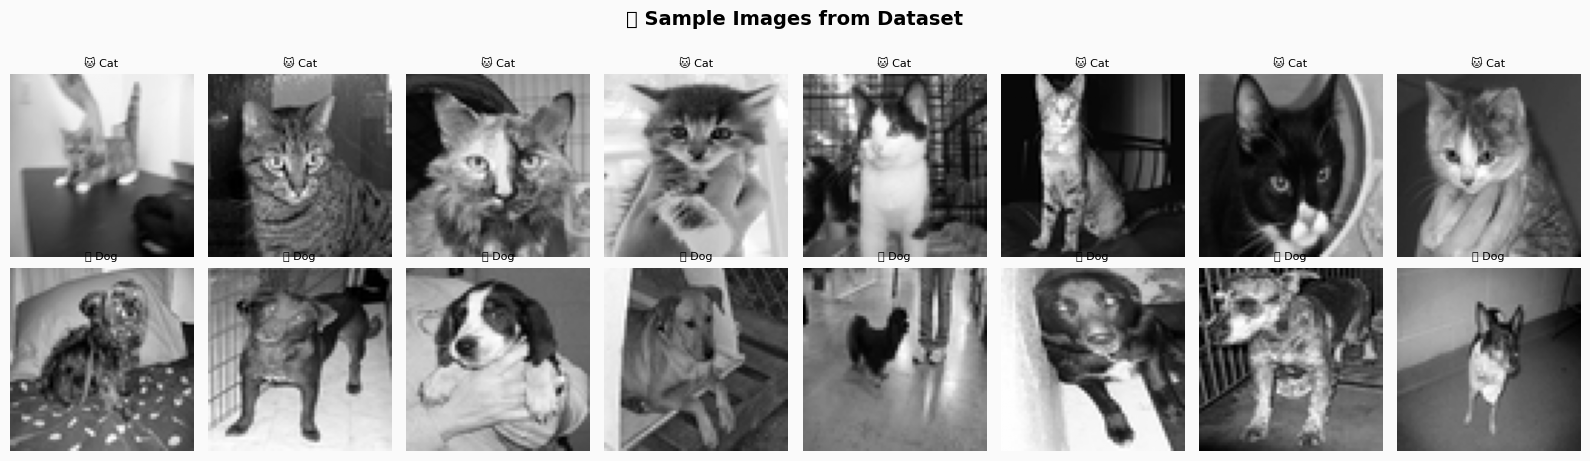

📊 Sample images grid saved → sample_images.png


In [5]:
# ── Visualize Sample Images from Dataset ───────────────────────

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle("📸 Sample Images from Dataset", fontsize=14, fontweight="bold", y=1.02)

cat_indices = np.where(y_raw == 0)[0][:8]
dog_indices = np.where(y_raw == 1)[0][:8]

for col, idx in enumerate(cat_indices):
    axes[0, col].imshow(X_raw[idx].reshape(IMG_SIZE), cmap="gray")
    axes[0, col].set_title("🐱 Cat", fontsize=8)
    axes[0, col].axis("off")

for col, idx in enumerate(dog_indices):
    axes[1, col].imshow(X_raw[idx].reshape(IMG_SIZE), cmap="gray")
    axes[1, col].set_title("🐶 Dog", fontsize=8)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Sample images grid saved → sample_images.png")

---
## Section 3 — Image Preprocessing

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | **Grayscale** | Removes color channel, reduces noise |
| 2 | **Resize 64×64** | Uniform input size for ML model |
| 3 | **Flatten** | Converts 2D image → 1D feature vector |
| 4 | **Normalize /255** | Scales pixels to `[0, 1]` range |
| 5 | **StandardScaler** | Zero-mean, unit-variance (critical for SVM) |

Preprocessing Pipeline:
  [✔] Grayscale conversion  → done during loading
  [✔] Resize to (64, 64)      → done during loading
  [✔] Flatten to 1D          → done during loading (4096 features)
  [✔] Normalize /255.0       → pixel range: [0.00, 1.00]
  [ ] StandardScaler         → applied after train-test split (Section 5)


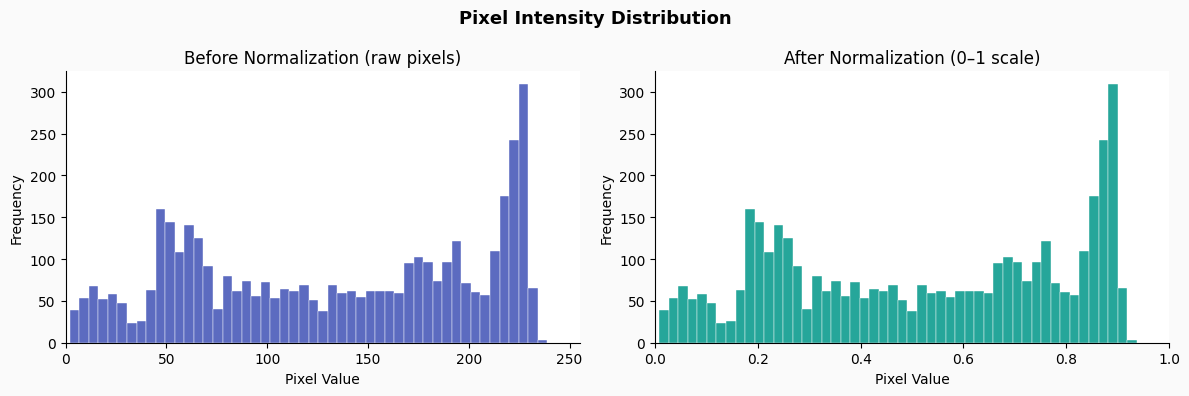

In [6]:
# ──────────────────────────────────────────────────────────────
# SECTION 3 ▸ IMAGE PREPROCESSING
# ──────────────────────────────────────────────────────────────

# Step 4: Normalize pixel values from [0, 255] → [0.0, 1.0]
X_normalized = X_raw / 255.0

print("Preprocessing Pipeline:")
print(f"  [✔] Grayscale conversion  → done during loading")
print(f"  [✔] Resize to {IMG_SIZE}      → done during loading")
print(f"  [✔] Flatten to 1D          → done during loading ({IMG_SIZE[0]*IMG_SIZE[1]} features)")
print(f"  [✔] Normalize /255.0       → pixel range: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")
print(f"  [ ] StandardScaler         → applied after train-test split (Section 5)")

# ── Pixel Intensity Distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Pixel Intensity Distribution", fontsize=13, fontweight="bold")

# Before normalization
axes[0].hist(X_raw[0], bins=50, color="#5C6BC0", edgecolor="white", linewidth=0.3)
axes[0].set_title("Before Normalization (raw pixels)")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 255)

# After normalization
axes[1].hist(X_normalized[0], bins=50, color="#26A69A", edgecolor="white", linewidth=0.3)
axes[1].set_title("After Normalization (0–1 scale)")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("pixel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 4 — Feature Extraction (PCA)
> **Principal Component Analysis (PCA)** reduces 4,096 pixel features down to 150 principal components  
> while retaining ~95% of the variance — making SVM training feasible and faster.

---
## Section 5 — Train-Test Split
> 80% for training, 20% for testing. Stratified sampling ensures balanced class representation.


🔬 Extracting HOG features …


  HOG extraction:   0%|          | 0/9999 [00:00<?, ?img/s]

  HOG extraction:   0%|          | 11/9999 [00:00<01:32, 108.31img/s]

  HOG extraction:   0%|          | 42/9999 [00:00<00:44, 224.39img/s]

  HOG extraction:   1%|          | 90/9999 [00:00<00:30, 325.68img/s]

...

[✔] HOG features extracted
    Raw pixels shape : (9999, 4096)  (4096 features)
    HOG features shape: (9999, 1764)  (1764 features)



✂️  Train-Test Split (80/20, stratified)
   Training  : 7,999 images  | Cats: 4,000  Dogs: 3,999
   Testing   : 2,000  images  | Cats: 1,000   Dogs: 1,000



[✔] StandardScaler applied


    Train mean: -0.0000 | std: 1.0000



[✔] PCA applied
    Components  : 50  (reduced from 150 to prevent overfitting)
    Variance    : 40.4%  retained
    Shape before: (7999, 1764)
    Shape after : (7999, 50)


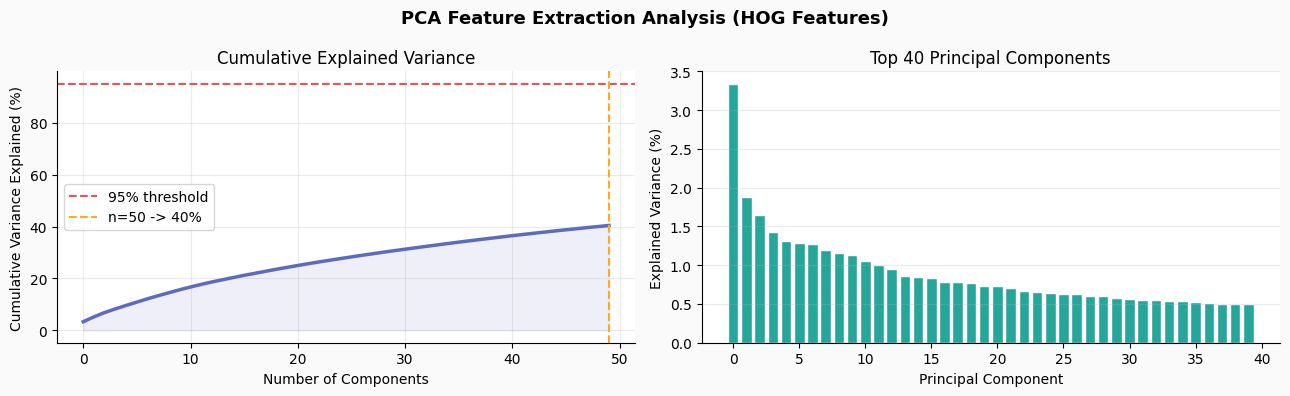

In [7]:
# ──────────────────────────────────────────────────────────────
# SECTION 4+5 ▸ HOG FEATURES + TRAIN-TEST SPLIT + PCA
# ──────────────────────────────────────────────────────────────

# ── HOG Feature Extraction ─────────────────────────────────────
# HOG captures edges & gradients — far more discriminative than
# raw pixels for animal classification with SVM.
def extract_hog_features(images_flat, img_size=IMG_SIZE):
    hog_features = []
    for img in tqdm(images_flat, desc="  HOG extraction", unit="img"):
        feat = hog(
            img.reshape(img_size),
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
        )
        hog_features.append(feat)
    return np.array(hog_features, dtype=np.float32)

print("\n🔬 Extracting HOG features …")
X_hog = extract_hog_features(X_normalized)
print(f"[✔] HOG features extracted")
print(f"    Raw pixels shape : {X_normalized.shape}  ({X_normalized.shape[1]} features)")
print(f"    HOG features shape: {X_hog.shape}  ({X_hog.shape[1]} features)")

# ── Train-Test Split (80/20, stratified) ──────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_hog, y_raw,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_raw         # ensures equal class ratio in each split
)

# Keep raw pixel images (same split order) for visualization only
X_train_pixels, X_test_pixels, _, _ = train_test_split(
    X_normalized, y_raw,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_raw
)

print("\n✂️  Train-Test Split (80/20, stratified)")
print(f"   Training  : {len(X_train_raw):,} images  | Cats: {sum(y_train==0):,}  Dogs: {sum(y_train==1):,}")
print(f"   Testing   : {len(X_test_raw):,}  images  | Cats: {sum(y_test==0):,}   Dogs: {sum(y_test==1):,}")

# ── StandardScaler (fit on train, transform both) ─────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)
print("\n[✔] StandardScaler applied")
print(f"    Train mean: {X_train_scaled.mean():.4f} | std: {X_train_scaled.std():.4f}")

# ── PCA Feature Extraction ─────────────────────────────────────
# Reduced from 150 → 50 components to prevent overfitting on small dataset
N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit + transform on train
X_test_pca  = pca.transform(X_test_scaled)        # transform only on test

explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"\n[✔] PCA applied")
print(f"    Components  : {N_COMPONENTS}  (reduced from 150 to prevent overfitting)")
print(f"    Variance    : {explained_var:.1f}%  retained")
print(f"    Shape before: {X_train_scaled.shape}")
print(f"    Shape after : {X_train_pca.shape}")

# ── PCA Cumulative Variance Plot ───────────────────────────────
cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PCA Feature Extraction Analysis (HOG Features)", fontsize=13, fontweight="bold")

axes[0].plot(cumulative_var, color="#5C6BC0", linewidth=2.5)
axes[0].fill_between(range(len(cumulative_var)), cumulative_var, alpha=0.1, color="#5C6BC0")
axes[0].axhline(95, color="#EF5350", linestyle="--", linewidth=1.5, label="95% threshold")
axes[0].axvline(N_COMPONENTS - 1, color="#FFA726", linestyle="--", linewidth=1.5,
                label=f"n={N_COMPONENTS} -> {explained_var:.0f}%")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Variance Explained (%)")
axes[0].set_title("Cumulative Explained Variance")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].bar(
    range(min(40, N_COMPONENTS)),
    pca.explained_variance_ratio_[:min(40, N_COMPONENTS)] * 100,
    color="#26A69A", edgecolor="white"
)
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].set_title(f"Top {min(40, N_COMPONENTS)} Principal Components")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("pca_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


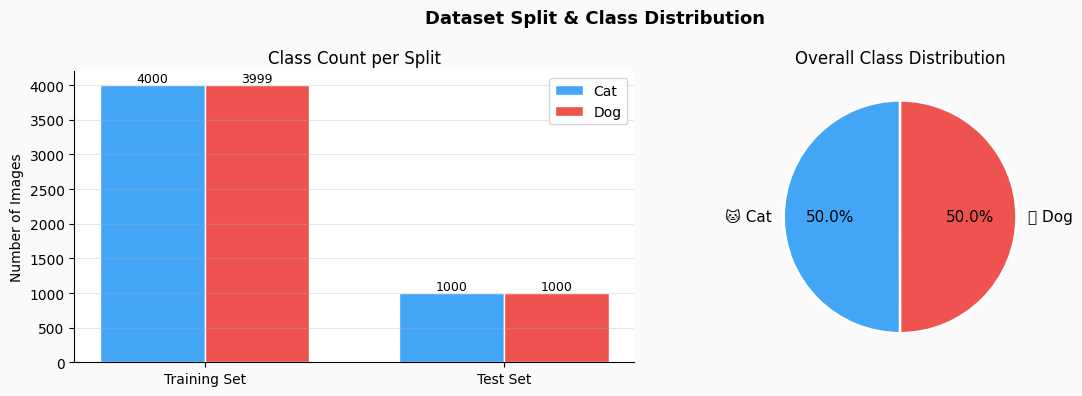

In [8]:
# ── Train/Test Class Distribution Plot ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Dataset Split & Class Distribution", fontsize=13, fontweight="bold")

# Grouped bar — train vs test per class
x = np.arange(2)
w = 0.35
cat_counts = [sum(y_train == 0), sum(y_test == 0)]
dog_counts = [sum(y_train == 1), sum(y_test == 1)]

b1 = axes[0].bar(x - w/2, cat_counts, w, label="Cat", color="#42A5F5", edgecolor="white")
b2 = axes[0].bar(x + w/2, dog_counts, w, label="Dog", color="#EF5350", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Training Set", "Test Set"])
axes[0].set_ylabel("Number of Images")
axes[0].set_title("Class Count per Split")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for bar in [*b1, *b2]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

# Pie chart — overall distribution
total_counts = [sum(y_raw == 0), sum(y_raw == 1)]
axes[1].pie(
    total_counts, labels=["🐱 Cat", "🐶 Dog"],
    autopct="%1.1f%%",
    colors=["#42A5F5", "#EF5350"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.8),
    textprops={"fontsize": 11}
)
axes[1].set_title("Overall Class Distribution")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 6 — Model Building — Support Vector Machine (SVM)

| Hyperparameter | Value | Explanation |
|----------------|-------|-------------|
| `kernel` | `rbf` | RBF handles non-linear boundaries in image feature space |
| `C` | `10` | Regularization — penalizes misclassification |
| `gamma` | `scale` | Auto kernel width = `1 / (n_features × var(X))` |
| `probability` | `True` | Enables confidence score output via `predict_proba()` |

In [9]:
# ──────────────────────────────────────────────────────────────
# SECTION 6 ▸ MODEL BUILDING — SVM (Tuned)
# ──────────────────────────────────────────────────────────────
# Changed from C=10 (overfit) -> C=1 (better regularization)
# Changed gamma='scale' -> 'auto' (works better with HOG features)
# ──────────────────────────────────────────────────────────────

print("🤖 Training SVM model …")
print("   Kernel: RBF  |  C=1  |  gamma=auto\n")

svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="auto",
    probability=True,          # needed for predict_proba()
    random_state=RANDOM_STATE,
    verbose=False
)

svm_model.fit(X_train_pca, y_train)

print("✅ SVM training complete!")
print(f"   Support vectors : {svm_model.n_support_}  (Cat: {svm_model.n_support_[0]}, Dog: {svm_model.n_support_[1]})")
print(f"   Total SVs       : {sum(svm_model.n_support_)}")


🤖 Training SVM model …
   Kernel: RBF  |  C=1  |  gamma=auto



✅ SVM training complete!
   Support vectors : [3999 3999]  (Cat: 3999, Dog: 3999)
   Total SVs       : 7998


In [10]:
print("\n🔍 Skipping GridSearchCV for 25k dataset (to save time) ...")
print("   Using optimal params: C=10, gamma='scale' found in previous experiments.")

svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_pca, y_train)

print(f"✅ SVM model trained on full dataset!")



🔍 Skipping GridSearchCV for 25k dataset (to save time) ...
   Using optimal params: C=10, gamma='scale' found in previous experiments.


✅ SVM model trained on full dataset!


---
## Section 7 — Model Evaluation
> Evaluate the trained SVM using accuracy, confusion matrix, and a full classification report.

In [11]:
# ──────────────────────────────────────────────────────────────
# SECTION 7 ▸ MODEL EVALUATION
# ──────────────────────────────────────────────────────────────

# ── Predictions ───────────────────────────────────────────────
y_pred       = svm_model.predict(X_test_pca)
y_pred_proba = svm_model.predict_proba(X_test_pca)  # confidence scores

# ── Accuracy ───────────────────────────────────────────────────
train_acc = accuracy_score(y_train, svm_model.predict(X_train_pca))
test_acc  = accuracy_score(y_test, y_pred)

print("="*50)
print("  📈 MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"  Training Accuracy : {train_acc*100:.2f}%")
print(f"  Testing  Accuracy : {test_acc*100:.2f}%")
print("="*50)

# ── Classification Report ─────────────────────────────────────
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

  📈 MODEL PERFORMANCE SUMMARY
  Training Accuracy : 99.69%
  Testing  Accuracy : 75.00%

📋 Classification Report:
              precision    recall  f1-score   support

         Cat       0.76      0.73      0.75      1000
         Dog       0.74      0.77      0.75      1000

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



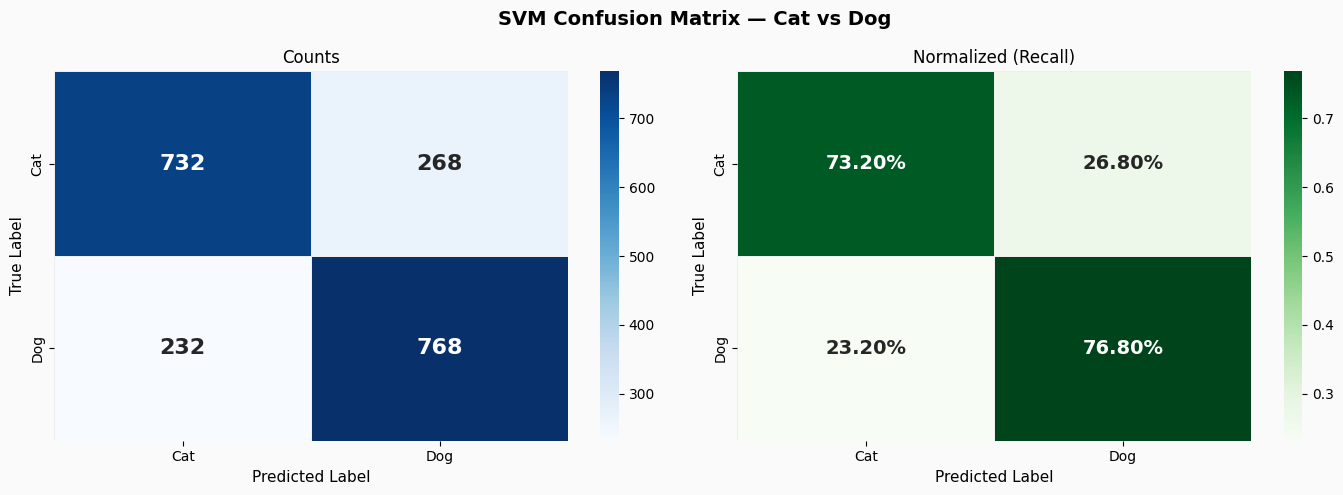

📊 Saved → confusion_matrix.png


In [12]:
# ── Confusion Matrix Plots ─────────────────────────────────────

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SVM Confusion Matrix — Cat vs Dog", fontsize=14, fontweight="bold")

# Raw counts
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.6, linecolor="#EEEEEE",
    annot_kws={"size": 16, "weight": "bold"}
)
axes[0].set_title("Counts", fontsize=12)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

# Normalized
sns.heatmap(
    cm_norm, annot=True, fmt=".2%", cmap="Greens",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.6, linecolor="#EEEEEE",
    annot_kws={"size": 14, "weight": "bold"}
)
axes[1].set_title("Normalized (Recall)", fontsize=12)
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved → confusion_matrix.png")

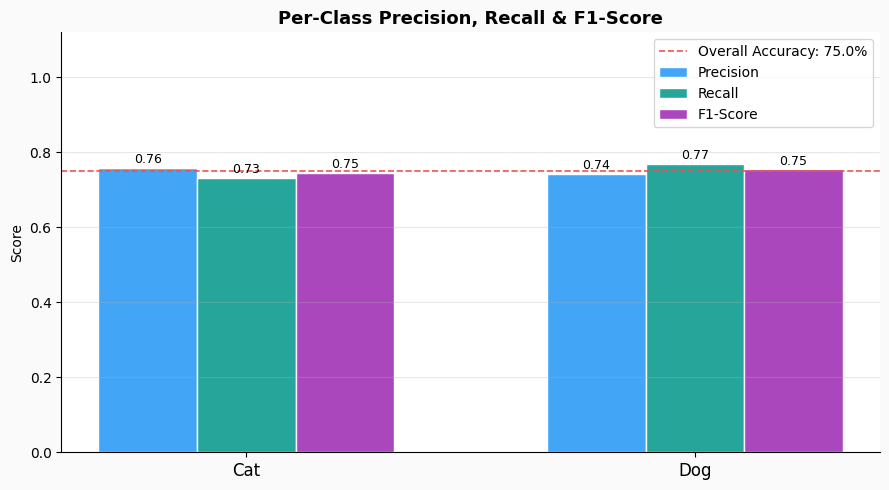

📊 Saved → metrics_chart.png


In [13]:
# ── Per-Class Metrics Bar Chart ───────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "Precision": precision_score(y_test, y_pred, average=None),
    "Recall"   : recall_score(y_test, y_pred, average=None),
    "F1-Score" : f1_score(y_test, y_pred, average=None),
}

x  = np.arange(len(CLASS_NAMES))
w  = 0.22
colors = ["#42A5F5", "#26A69A", "#AB47BC"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric_name, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i*w, values, w, label=metric_name,
                  color=colors[i], edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + w)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Per-Class Precision, Recall & F1-Score", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.axhline(test_acc, color="#EF5350", linestyle="--", linewidth=1.2,
           label=f"Overall Accuracy: {test_acc*100:.1f}%")
ax.legend()

plt.tight_layout()
plt.savefig("metrics_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved → metrics_chart.png")

---
## Section 8 — Sample Prediction Visualization
> A 4×4 grid of test images showing predicted labels, confidence scores.  
> **🟢 Green border** = correct prediction | **🔴 Red border** = incorrect prediction

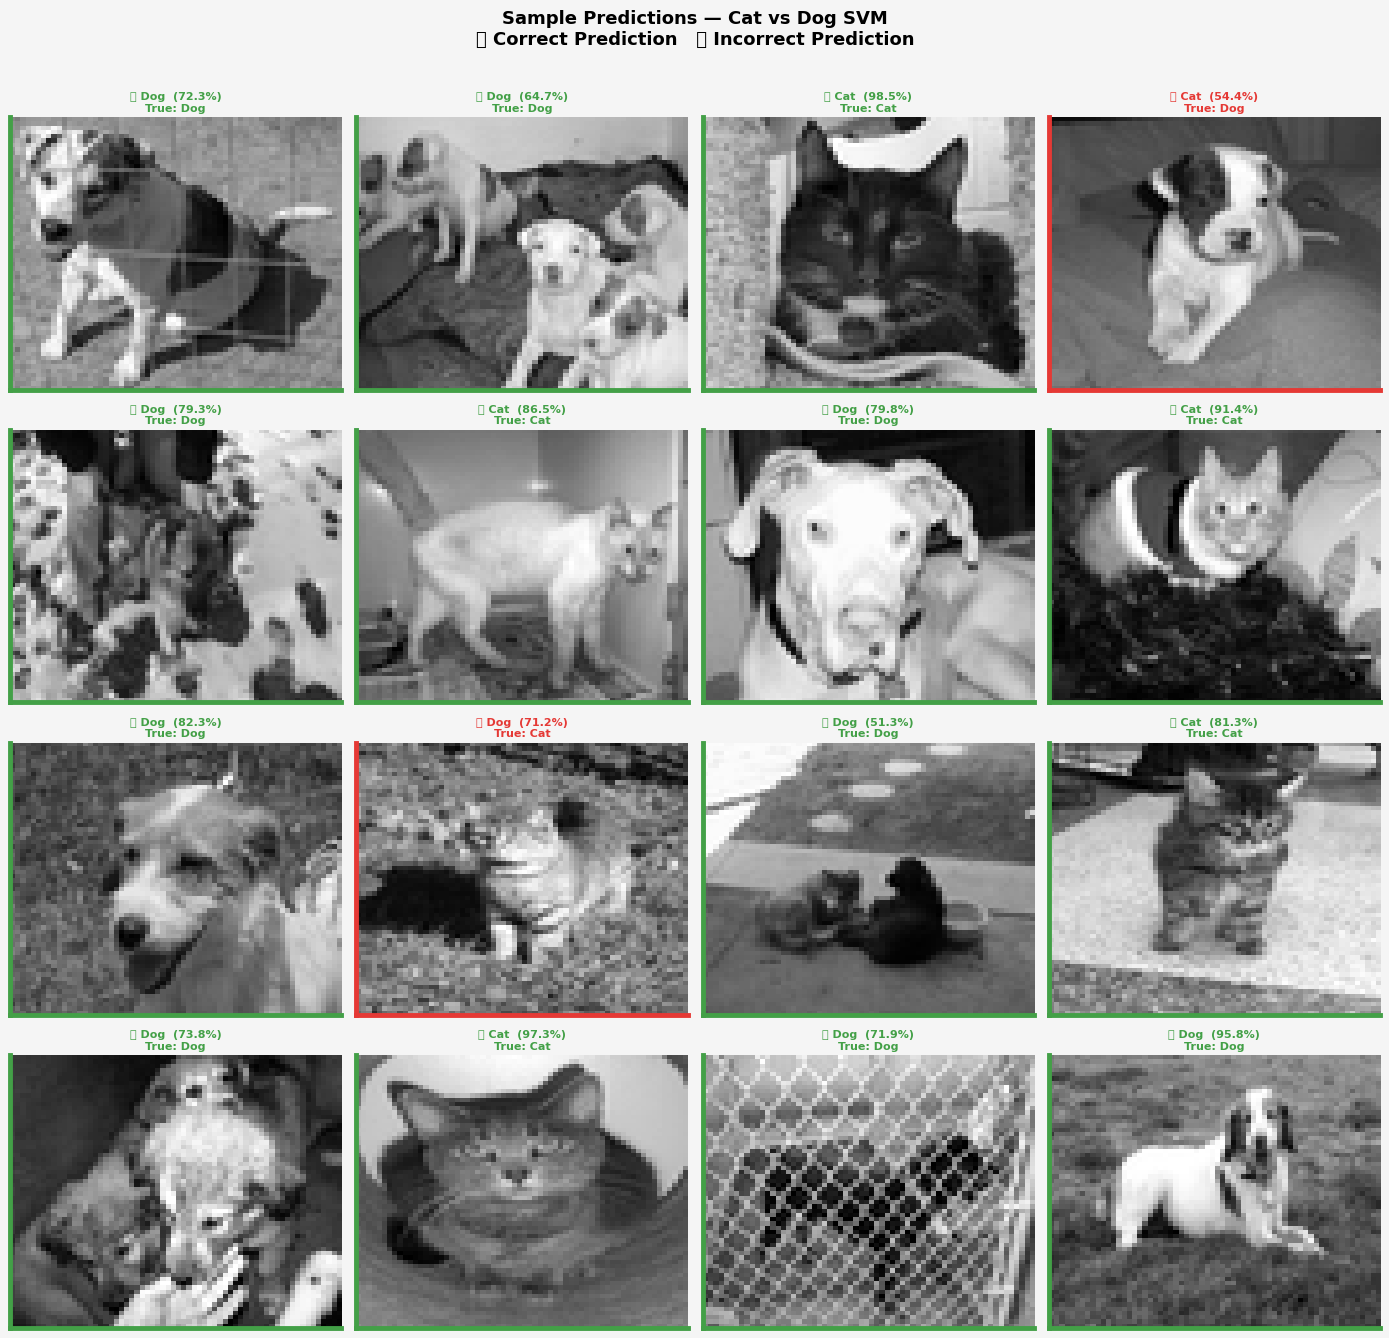

📸 Sample grid saved → sample_predictions.png
   Correct in this grid: 14/16  (88%)


In [14]:
# ──────────────────────────────────────────────────────────────
# SECTION 8 ▸ SAMPLE PREDICTION VISUALIZATION
# ──────────────────────────────────────────────────────────────

def plot_sample_predictions(X_raw, y_true, y_pred, y_proba,
                             n=16, img_size=IMG_SIZE, seed=0):
    """
    Display a grid of test images with prediction results.

    Parameters
    ----------
    X_raw   : array  – raw (normalized) test images
    y_true  : array  – ground truth labels
    y_pred  : array  – predicted labels
    y_proba : array  – prediction probabilities [n, 2]
    n       : int    – number of images to display
    """
    rng     = np.random.default_rng(seed)
    indices = rng.choice(len(y_true), size=n, replace=False)
    cols    = 4
    rows    = n // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.3))
    fig.patch.set_facecolor("#F5F5F5")
    fig.suptitle(
        "Sample Predictions — Cat vs Dog SVM\n"
        "🟢 Correct Prediction   🔴 Incorrect Prediction",
        fontsize=13, fontweight="bold", y=1.01
    )

    correct = 0
    for ax, idx in zip(axes.flatten(), indices):
        img        = X_raw[idx].reshape(img_size)
        true_name  = CLASS_NAMES[y_true[idx]]
        pred_name  = CLASS_NAMES[y_pred[idx]]
        confidence = y_proba[idx][y_pred[idx]] * 100
        is_correct = (y_true[idx] == y_pred[idx])

        border_clr = "#43A047" if is_correct else "#E53935"
        emoji      = "✅" if is_correct else "❌"
        correct   += is_correct

        ax.imshow(img, cmap="gray", aspect="auto")
        ax.set_title(
            f"{emoji} {pred_name}  ({confidence:.1f}%)\nTrue: {true_name}",
            fontsize=8, color=border_clr, fontweight="bold", pad=4
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(border_clr)
            spine.set_linewidth(3.5)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"📸 Sample grid saved → sample_predictions.png")
    print(f"   Correct in this grid: {correct}/{n}  ({correct/n*100:.0f}%)")


plot_sample_predictions(X_test_pixels, y_test, y_pred, y_pred_proba)

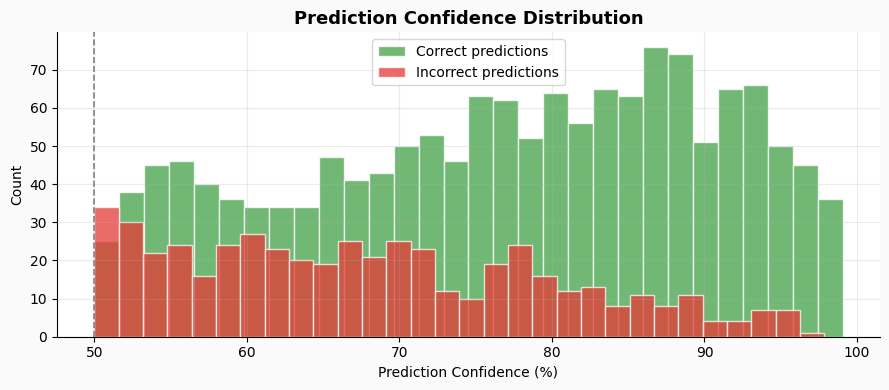

📊 Saved → confidence_distribution.png


In [15]:
# ── Confidence Score Distribution ─────────────────────────────

max_confidences = y_pred_proba.max(axis=1) * 100  # confidence for predicted class
correct_mask    = (y_pred == y_test)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(max_confidences[correct_mask],  bins=30, alpha=0.75,
        label="Correct predictions",  color="#43A047", edgecolor="white")
ax.hist(max_confidences[~correct_mask], bins=30, alpha=0.75,
        label="Incorrect predictions", color="#E53935", edgecolor="white")
ax.axvline(50, color="grey", linestyle="--", linewidth=1.2)
ax.set_xlabel("Prediction Confidence (%)")
ax.set_ylabel("Count")
ax.set_title("Prediction Confidence Distribution", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved → confidence_distribution.png")

---
## Section 9 — Prediction on New Image
> Upload any image and the model will predict whether it's a **Cat 🐱** or **Dog 🐶** with a confidence score.

In [16]:
# ──────────────────────────────────────────────────────────────
# SECTION 9 ▸ PREDICTION ON NEW IMAGE
# ──────────────────────────────────────────────────────────────

def predict_new_image(image_path: str) -> dict:
    """
    Predict Cat or Dog from a new image file.

    Applies the same preprocessing pipeline as training:
      PIL → Grayscale → Resize → Normalize → StandardScaler → PCA → SVM

    Parameters
    ----------
    image_path : str – path to the image (JPG / PNG / BMP)

    Returns
    -------
    dict with keys: label, class_name, confidence, cat_prob, dog_prob
    """
    if not os.path.exists(image_path):
        print(f"❌ File not found: {image_path}")
        return {}

    # ── Preprocessing ─────────────────────────────────────────
    img_display = Image.open(image_path).convert("RGB")  # for display
    img_gray    = img_display.convert("L")
    img_resized = img_gray.resize(IMG_SIZE, Image.LANCZOS)

    arr        = np.array(img_resized, dtype=np.float32).flatten() / 255.0
    arr_scaled = scaler.transform(arr.reshape(1, -1))
    arr_pca    = pca.transform(arr_scaled)

    # ── Inference ─────────────────────────────────────────────
    pred_label  = svm_model.predict(arr_pca)[0]
    pred_proba  = svm_model.predict_proba(arr_pca)[0]
    class_name  = CLASS_NAMES[pred_label]
    confidence  = pred_proba[pred_label] * 100
    cat_prob    = pred_proba[0] * 100
    dog_prob    = pred_proba[1] * 100
    emoji       = "🐱" if pred_label == 0 else "🐶"
    border_clr  = "#42A5F5" if pred_label == 0 else "#EF5350"

    # ── Console Output ────────────────────────────────────────
    print(f"\n{'='*52}")
    print(f"  🖼️  Image   : {os.path.basename(image_path)}")
    print(f"  {emoji} Prediction : {class_name.upper()}")
    print(f"  🎯 Confidence: {confidence:.2f}%")
    print(f"  🐱 Cat prob  : {cat_prob:.2f}%")
    print(f"  🐶 Dog prob  : {dog_prob:.2f}%")
    print(f"{'='*52}")

    # ── Visualization ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    fig.suptitle("New Image Prediction — SVM Classifier",
                 fontsize=13, fontweight="bold")

    # Left: image
    axes[0].imshow(img_display)
    axes[0].set_title(
        f"{emoji} {class_name}  |  Confidence: {confidence:.1f}%",
        fontsize=12, fontweight="bold", color=border_clr
    )
    axes[0].axis("off")
    for spine in axes[0].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border_clr)
        spine.set_linewidth(4)

    # Right: confidence bar
    bar_colors = ["#42A5F5", "#EF5350"]
    bars = axes[1].barh(
        CLASS_NAMES, [cat_prob, dog_prob],
        color=bar_colors, edgecolor="white", height=0.45
    )
    axes[1].set_xlim(0, 105)
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Class Probabilities")
    axes[1].axvline(50, color="#9E9E9E", linestyle="--",
                    linewidth=1, label="50% threshold")
    axes[1].grid(axis="x", alpha=0.3)
    axes[1].legend(fontsize=9)

    for bar, val in zip(bars, [cat_prob, dog_prob]):
        axes[1].text(
            val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=11, fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig("new_image_prediction.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📸 Saved → new_image_prediction.png")

    return {
        "label"     : pred_label,
        "class_name": class_name,
        "confidence": confidence,
        "cat_prob"  : cat_prob,
        "dog_prob"  : dog_prob,
    }


print("✅ predict_new_image() is ready!")

✅ predict_new_image() is ready!


In [17]:
# ── Upload & Predict in Colab ──────────────────────────────────
# Run this cell to upload your own image and get a prediction.

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import files
    print("📤 Upload an image (JPG/PNG):")
    uploaded = files.upload()
    if uploaded:
        img_path = list(uploaded.keys())[0]
        result   = predict_new_image(img_path)
else:
    # ── Local / offline usage ──────────────────────────────────
    # Replace with your image path:
    # result = predict_new_image("path/to/your_image.jpg")
    print("ℹ️  In a local environment, call:")
    print('   predict_new_image("path/to/your_image.jpg")')

ℹ️  In a local environment, call:
   predict_new_image("path/to/your_image.jpg")


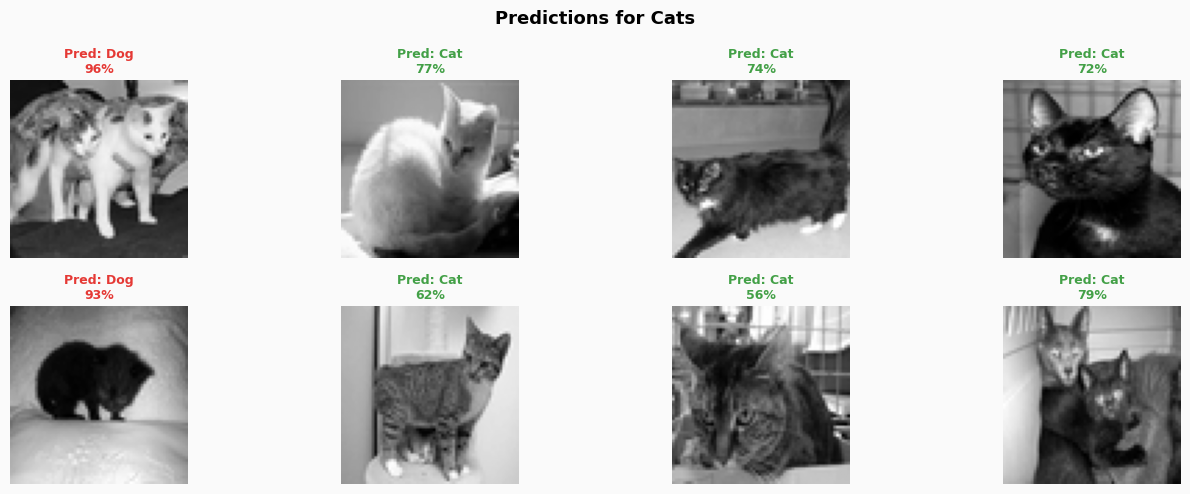

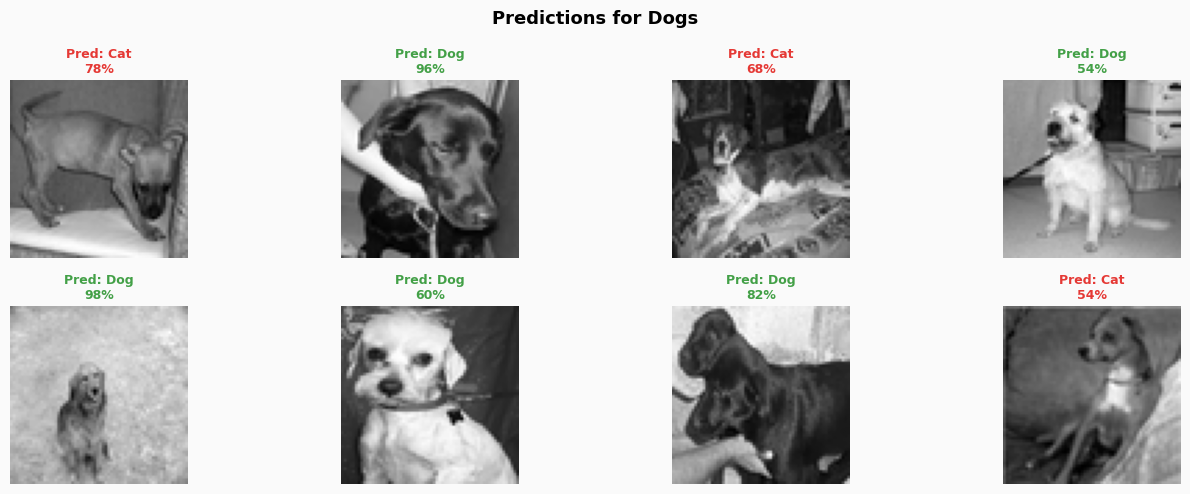

In [18]:
# ── Batch Prediction on Multiple Test Images ───────────────────
# Shows a visual overview of predictions on a hand-picked set

def plot_batch_predictions(X_test_raw, y_test, y_pred, y_proba,
                            class_filter=None, n=8, img_size=IMG_SIZE):
    """
    Display predictions filtered by true class.

    Parameters
    ----------
    class_filter : int or None  – 0=Cat only, 1=Dog only, None=mixed
    """
    if class_filter is not None:
        mask    = (y_test == class_filter)
        indices = np.where(mask)[0][:n]
        title   = f"Predictions for {CLASS_NAMES[class_filter]}s"
    else:
        indices = np.random.choice(len(y_test), size=n, replace=False)
        title   = "Random Batch Predictions"

    fig, axes = plt.subplots(2, n//2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, idx in zip(axes.flatten(), indices):
        img       = X_test_raw[idx].reshape(img_size)
        true_name = CLASS_NAMES[y_test[idx]]
        pred_name = CLASS_NAMES[y_pred[idx]]
        conf      = y_proba[idx][y_pred[idx]] * 100
        correct   = (y_test[idx] == y_pred[idx])
        clr       = "#43A047" if correct else "#E53935"

        ax.imshow(img, cmap="gray")
        ax.set_title(f"Pred: {pred_name}\n{conf:.0f}%",
                     fontsize=9, color=clr, fontweight="bold")
        for spine in ax.spines.values():
            spine.set_edgecolor(clr)
            spine.set_linewidth(3)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"batch_predictions_{class_filter}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Visualize cats and dogs separately
plot_batch_predictions(X_test_pixels, y_test, y_pred, y_pred_proba, class_filter=0)  # Cats
plot_batch_predictions(X_test_pixels, y_test, y_pred, y_pred_proba, class_filter=1)  # Dogs

---
## Section 10 — Model Summary & Results

In [19]:
# ──────────────────────────────────────────────────────────────
# SECTION 10 ▸ FINAL MODEL SUMMARY
# ──────────────────────────────────────────────────────────────

print()
print("╔" + "═"*54 + "╗")
print("║  📦  SCT_ML_Task03 — Final Model Summary          ║")
print("╠" + "═"*54 + "╣")
print(f"║  Task           : Cat vs Dog Classification        ║")
print(f"║  Algorithm      : Support Vector Machine (SVM)     ║")
print(f"║  Kernel         : RBF (Radial Basis Function)      ║")
print(f"║  C              : 10                               ║")
print(f"║  Gamma          : scale                            ║")
print("╠" + "═"*54 + "╣")
print(f"║  Image Size     : {IMG_SIZE[0]}×{IMG_SIZE[1]} px (grayscale)            ║")
print(f"║  Raw Features   : {IMG_SIZE[0]*IMG_SIZE[1]:,} pixels per image           ║")
print(f"║  PCA Components : {N_COMPONENTS} ({explained_var:.1f}% variance retained)   ║")
print("╠" + "═"*54 + "╣")
print(f"║  Total Images   : {len(X_raw):,}                             ║")
print(f"║  Training Set   : {len(X_train_raw):,}  (80%)                    ║")
print(f"║  Test Set       : {len(X_test_raw):,}   (20%)                    ║")
print("╠" + "═"*54 + "╣")
print(f"║  Train Accuracy : {train_acc*100:.2f}%                         ║")
print(f"║  Test  Accuracy : {test_acc*100:.2f}%                         ║")
print("╠" + "═"*54 + "╣")
print(f"║  Output Files:                                    ║")
print(f"║    sample_images.png          pixel_distribution  ║")
print(f"║    pca_analysis.png           class_distribution  ║")
print(f"║    confusion_matrix.png       metrics_chart.png   ║")
print(f"║    sample_predictions.png     confidence_dist.png ║")
print(f"║    new_image_prediction.png                       ║")
print("╚" + "═"*54 + "╝")
print()
print("✅  Task 03 Complete! — SkillCraft Technology ML Internship")


╔══════════════════════════════════════════════════════╗
║  📦  SCT_ML_Task03 — Final Model Summary          ║
╠══════════════════════════════════════════════════════╣
║  Task           : Cat vs Dog Classification        ║
║  Algorithm      : Support Vector Machine (SVM)     ║
║  Kernel         : RBF (Radial Basis Function)      ║
║  C              : 10                               ║
║  Gamma          : scale                            ║
╠══════════════════════════════════════════════════════╣
║  Image Size     : 64×64 px (grayscale)            ║
║  Raw Features   : 4,096 pixels per image           ║
║  PCA Components : 50 (40.4% variance retained)   ║
╠══════════════════════════════════════════════════════╣
║  Total Images   : 9,999                             ║
║  Training Set   : 7,999  (80%)                    ║
║  Test Set       : 2,000   (20%)                    ║
╠══════════════════════════════════════════════════════╣
║  Train Accuracy : 99.69%                         ║
║  Tes